# `jlegroup` — package overview

*Named for James Ludlow Elliot (1943–2011) — author of the methods implemented here, and mentor to this package's maintainer.*

**`jlegroup`** is the MIT Elliot-group stellar-occultation toolkit: forward modeling **and** inversion of occultation light curves for small-planet atmospheres, from three companion methods with a common author:

| module | method paper | role |
|---|---|---|
| `jlegroup.EY92` | Elliot & Young 1992, AJ 103, 991 | **analytic forward model** — power-law small-planet atmospheres, haze, far limb / central flash |
| `jlegroup.CE97` | Chamberlain & Elliot 1997, PASP 109, 1170 | **numerical forward model** — light curves from an *arbitrary* refractivity profile ν(r) |
| `jlegroup.EPQ03` | Elliot, Person & Qu 2003, AJ 126, 1041 | **inversion** — temperature/pressure/density retrieval with full error propagation |
| `jlegroup.physicalData` | port of Mathematica ``jleGroup`physicalData`` | constants, gas refractivities, body data — pinned to the CODATA-1986 validation vintage |

**Lineage:** original Python implementation by Wata (Chanita) Tubthong (2021), extended by William Saunders (2021), packaged, validated, and maintained by Michael J. Person (2026). All-lowercase `jlegroup` is this Python package; camelCase `jleGroup` is the original Mathematica family.

**Install** (collaborators on the private repo): `pip install git+https://github.com/mjperson/jlegroup.git`

Per-method tutorials live beside this notebook:
[`01_EY92_basics.ipynb`](01_EY92_basics.ipynb) · [`02_CE97_basics.ipynb`](02_CE97_basics.ipynb) · [`03_EPQ03_basics.ipynb`](03_EPQ03_basics.ipynb)

Below: the whole package in one exercise — generate a light curve analytically (EY92), reproduce it numerically (CE97), then invert it (EPQ03) and recover the atmosphere we started from.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jlegroup
from jlegroup import CE97, EY92, EPQ03, physicalData

print("jlegroup", jlegroup.__version__, "| numpy", np.__version__)

jlegroup 0.10.0 | numpy 2.5.0


## 1. One atmosphere, two forward models

The test atmosphere is EPQ03's Table-1 standard case: isothermal 80 K N₂ at 30 AU, half-light radius $r_h = 1200$ km, energy ratio $\lambda_h = 40$ (so the scale height is $H_h = r_h/\lambda_h = 30$ km). `EPQ03.ModelAtmosphere` carries this parameterization and the body mass it implies (EPQ03 Eq. 60).

**EY92** evaluates the light curve analytically. **CE97** integrates the *same* refractivity profile numerically, knowing nothing about power laws — so their agreement is a method-independent cross-check (this is exactly how the package validates itself; see the README table).

In [2]:
atm = EPQ03.STANDARD_CASE          # r_h=1200 km, lambda_h=40, isothermal 80 K N2 at 30 AU
M_p = atm.mass()                   # body mass implied by (lambda_h, r_h, T_h, mu)  [Eq. 60]
print(f"standard case: r_h={atm.r_h:.0f} km, lambda_h={atm.lambda_h:.0f}, "
      f"H_h={atm.h_h:.1f} km, M_p={M_p:.4e} kg")

# --- analytic light curve (EY92), immersion order: y descending, 0.5 km steps
y, phi_ey92 = EPQ03.generate_light_curve(atm, y_top=1600.0, y_bottom=440.0)

# --- the same atmosphere through the numerical model (CE97)
r_probe = atm.radius_of_y(y)                       # body radii the rays actually probe
r_grid = np.arange(r_probe.min() - 25.0, 1900.0, 0.5)
nu_grid = EY92.refractivity_profile(r_grid, atm.r_h, atm.nu_h, atm.lambda_h, 0.0, atm.b)

ce97 = CE97.ChamberlainElliot1997Model(nu_grid, r_grid, atm.d, y[::-1])  # ascending y
ce97.main()
phi_ce97 = np.asarray(ce97.focusedFlux, float)[::-1]

resid = phi_ce97 - phi_ey92
print(f"CE97 - EY92: max |diff| = {np.abs(resid).max():.2e}, "
      f"RMS = {np.sqrt(np.mean(resid**2)):.2e}")

standard case: r_h=1200 km, lambda_h=40, H_h=30.0 km, M_p=1.7078e+22 kg
CE97 - EY92: max |diff| = 2.76e-06, RMS = 7.64e-07


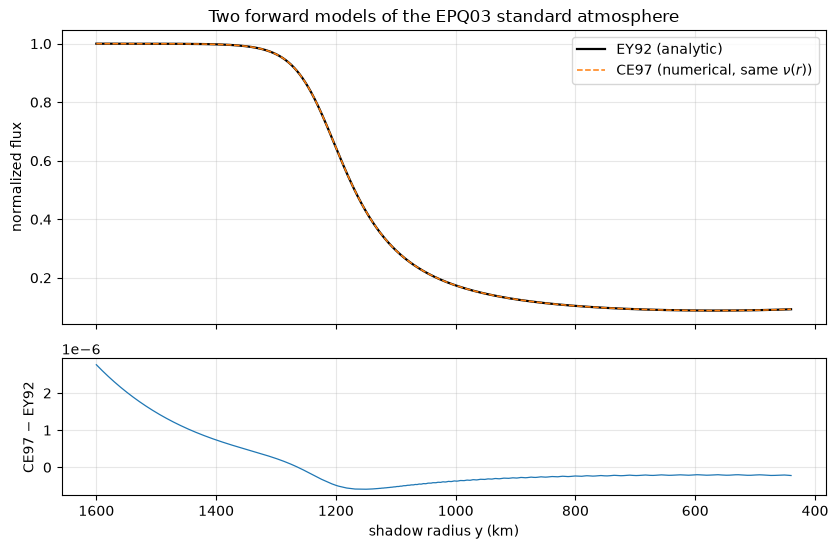

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(8.5, 5.6), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1.4]})
ax[0].plot(y, phi_ey92, "k-", lw=1.6, label="EY92 (analytic)")
ax[0].plot(y, phi_ce97, "--", color="C1", lw=1.1, label="CE97 (numerical, same $\\nu(r)$)")
ax[0].set_ylabel("normalized flux"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Two forward models of the EPQ03 standard atmosphere")
ax[1].plot(y, resid, lw=0.9)
ax[1].set_xlabel("shadow radius y (km)"); ax[1].set_ylabel("CE97 $-$ EY92")
ax[1].grid(alpha=0.3)
ax[0].invert_xaxis()          # immersion: time runs left to right
fig.tight_layout()

## 2. ...and back again: inversion (EPQ03)

`EPQ03.invert_light_curve` takes the light curve plus three physical facts — observer distance, gas, body mass — fits an EY92 boundary model to the data above half light, and inverts everything below the boundary into refractivity, number-density, pressure, and temperature profiles. On this noiseless curve the boundary fit should recover the generating parameters essentially exactly, and the retrieved temperature should be the 80 K we put in.

In [4]:
res = EPQ03.invert_light_curve(y, phi_ey92, d=atm.d, gas=atm.gas, m_p=M_p,
                               order=atm.order)
bc = res.boundary
print("boundary fit vs truth:")
print(f"  r_h       = {bc.r_h:.6f} km   (true {atm.r_h})")
print(f"  lambda_hi = {bc.lambda_hi:.6f}      (true {atm.lambda_hi})")
print(f"  b         = {bc.b:.2e}       (true {atm.b})")
t = res.temperature
print(f"retrieved T, 10 deepest shells: {t[-10:].mean():.4f} K   (input 80)")

boundary fit vs truth:
  r_h       = 1200.000000 km   (true 1200.0)
  lambda_hi = 40.000000      (true 40.0)
  b         = 3.90e-11       (true 0.0)
retrieved T, 10 deepest shells: 79.9978 K   (input 80)


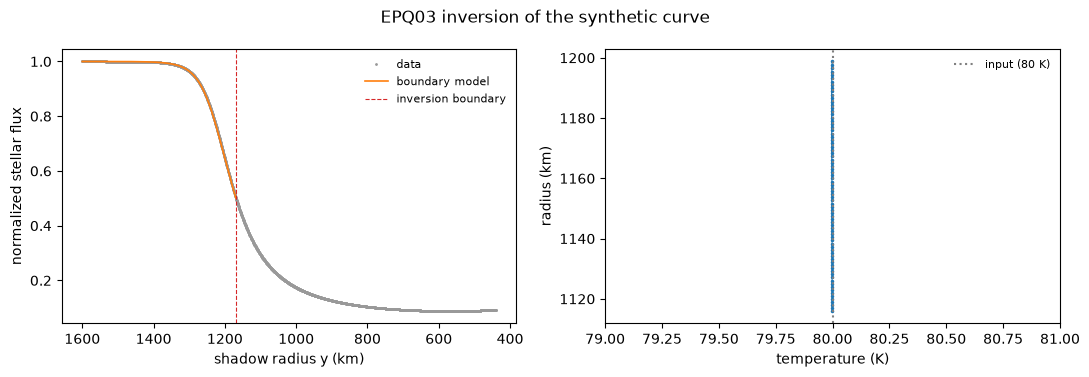

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
EPQ03.plot_light_curve(res, ax=ax[0])
EPQ03.plot_temperature(res, ax=ax[1])
ax[1].axvline(80.0, color="gray", ls=":", label="input (80 K)")
ax[1].set_xlim(79, 81); ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("EPQ03 inversion of the synthetic curve")
fig.tight_layout()

## 3. Where to go next

- [`01_EY92_basics.ipynb`](01_EY92_basics.ipynb) — the analytic model: parameters, series order (and the published-misprint corrections), haze, and the two-limb **central flash**.
- [`02_CE97_basics.ipynb`](02_CE97_basics.ipynb) — the numerical model: building atmospheres (including arbitrary $T(r)$ layers), the validation suite, and the atmosphere-top gotcha.
- [`03_EPQ03_basics.ipynb`](03_EPQ03_basics.ipynb) — inversion on noisy data with the full EPQ03 error budget.

**Three package-wide rules** (each notebook elaborates):
1. Constants come from `jlegroup.physicalData` in **two test-pinned vintages**, switched per model via `constants=`: the default is **CODATA-2022** (current research values); pass `constants=physicalData.CODATA1986` — the Mathematica jleGroup vintage — when reproducing validation references or published tables. The dominant difference is G (+2.6×10⁻⁴ relative).
2. CE97 and EPQ03 are **refraction-only, clear-atmosphere, one-limb** as validated; EY92 adds the paper's haze-absorption layer and the two-limb central flash.
3. Watch the validity edges: CE97's spline extrapolation above the atmosphere top, EY92's series truncation at steep thermal gradients, EPQ03's sensitivity to light-curve normalization.

**Citing:** cite the method paper(s) you use and the package (`CITATION.cff`).
**Status:** private during development; MIT license — lineage permissions in progress.